# SEP Pitch-angle distribution (PAD) and first-order anisotropies

This tool visualizes SEP pitch-angle distributions based on sectored measurements, and determines the first-order anisotropy of the SEP PAD including different methods. 

The tool includes pre-event background subtraction, for which the selected background interval is fitted (using potentially time-dependent models) and extrapolated into the future.

The steps of the tool are:
1. Make selections:

    a) Choose spacecraft and instrument from menu (radio buttons)
   
    b) Print available energy channels of the instrument
   
    c) Choose particle species, energy channel, and time averaging
   
    d) Choose time interval and load data. An overview plot shows.
2. Background analysis:
    
    a) choose and tweak background time interval (using the output plot) for background subtraction 
3. Determine 1st-order anisotropies
    
    a) Choose method to determine anisotropies.
   
    b) Change 'corr_window_end' under point 2 to change the interval for which the background-subtracted anisotropy is determined

In [1]:
from anisotropy import run_SEPevent, select_sc_inst, print_available_channels
from seppy.util import jupyterhub_data_path
import datetime as dt
import numpy as np
import os
import pandas as pd

### Saving figures

You can usually save a figure from the Notebook by right-clicking on it while holding down the ⇧ Shift key, then select "Save Image As..." (or similar).

### Select a local folder to save the downloaded data. If run on the project's JupyterHub server, it's set to a common data folder in the base directory. 

In [2]:
data_path = f"{os.getcwd()}{os.sep}data"
data_path = jupyterhub_data_path(data_path)

### Select Spacecraft & Instrument, particle species, and energy channel

In [3]:
spacecraft_instrument = select_sc_inst()

RadioButtons(description='Spacecraft & instrument:', index=4, layout=Layout(width='max-content'), options=('So…

In [19]:
print_available_channels(spacecraft_instrument.value)

Solar Orbiter EPT
Protons/Ions:
 channel              energy
       0 0.0495 - 0.0574 MeV
       1 0.0520 - 0.0602 MeV
       2 0.0552 - 0.0627 MeV
       3 0.0578 - 0.0651 MeV
       4 0.0608 - 0.0678 MeV
       5 0.0645 - 0.0718 MeV
       6 0.0689 - 0.0758 MeV
       7 0.0729 - 0.0798 MeV
       8 0.0768 - 0.0834 MeV
       9 0.0809 - 0.0870 MeV
      10 0.0870 - 0.0913 MeV
      11 0.0913 - 0.0974 MeV
      12 0.0974 - 0.1034 MeV
      13 0.1034 - 0.1096 MeV
      14 0.1096 - 0.1173 MeV
      15 0.1173 - 0.1246 MeV
      16 0.1246 - 0.1333 MeV
      17 0.1333 - 0.1419 MeV
      18 0.1419 - 0.1514 MeV
      19 0.1514 - 0.1628 MeV
      20 0.1628 - 0.1744 MeV
      21 0.1744 - 0.1879 MeV
      22 0.1879 - 0.2033 MeV
      23 0.2033 - 0.2189 MeV
      24 0.2189 - 0.2364 MeV
      25 0.2364 - 0.2549 MeV
      26 0.2549 - 0.2744 MeV
      27 0.2744 - 0.2980 MeV
      28 0.2980 - 0.3216 MeV
      29 0.3216 - 0.3494 MeV
      30 0.3494 - 0.3810 MeV
      31 0.3810 - 0.4117 MeV
      32 0.

# Select species, energy channel, and time averaging

In [20]:
species = "e"
channels = 15
averaging = "1min"  # time averaging. Set to None for no averaging (i.e., original resolution)

# Set data loading and plotting window

Spacecraft: Solar Orbiter
Instrument: EPT. Species: e. Channels: 15.
Creating dir c:\Users\osant\Desktop\heliophysics\sep_tools\data\l2\epd\ept\


c:\Users\osant\Desktop\heliophysics\sep_tools\data\l2\epd\ept\solo_L2_epd-ept-asun-rates_20211028_V02.cdf: 5.51MB [00:04, 1.31MB/s]                            
c:\Users\osant\Desktop\heliophysics\sep_tools\data\l2\epd\ept\solo_L2_epd-ept-asun-rates_20211029_V02.cdf: 12.2MB [00:08, 1.43MB/s]                            
c:\Users\osant\Desktop\heliophysics\sep_tools\data\l2\epd\ept\solo_L2_epd-ept-asun-rates_20211030_V02.cdf: 17.1MB [00:11, 1.48MB/s]                            
c:\Users\osant\Desktop\heliophysics\sep_tools\data\l2\epd\ept\solo_L2_epd-ept-north-rates_20211028_V02.cdf: 5.89MB [00:04, 1.41MB/s]                            
c:\Users\osant\Desktop\heliophysics\sep_tools\data\l2\epd\ept\solo_L2_epd-ept-north-rates_20211029_V02.cdf: 14.3MB [00:09, 1.51MB/s]                            
c:\Users\osant\Desktop\heliophysics\sep_tools\data\l2\epd\ept\solo_L2_epd-ept-north-rates_20211030_V02.cdf: 18.4MB [00:12, 1.49MB/s]                            
c:\Users\osant\Desktop\heliophysics\s

Cadence is 1.0 s.
Loading MAG...


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

solo_l2_mag-srf-normal_20211028_v02.cdf:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

...

solo_l2_mag-rtn-normal_20211030_v02.cdf:   0%|          | 0.00/13.0M [00:00<?, ?B/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

solo_l2_mag-rtn-normal_20211031_v02.cdf:   0%|          | 0.00/13.0M [00:00<?, ?B/s]

RED = INWARD, negative polarity, [90, 270] degrees
BLUE = OUTWARD, positive polarity, [270, 360] and [0, 90] degrees
Calculating PA coverage for EPT...


  0%|          | 0/2880 [00:00<?, ?it/s]

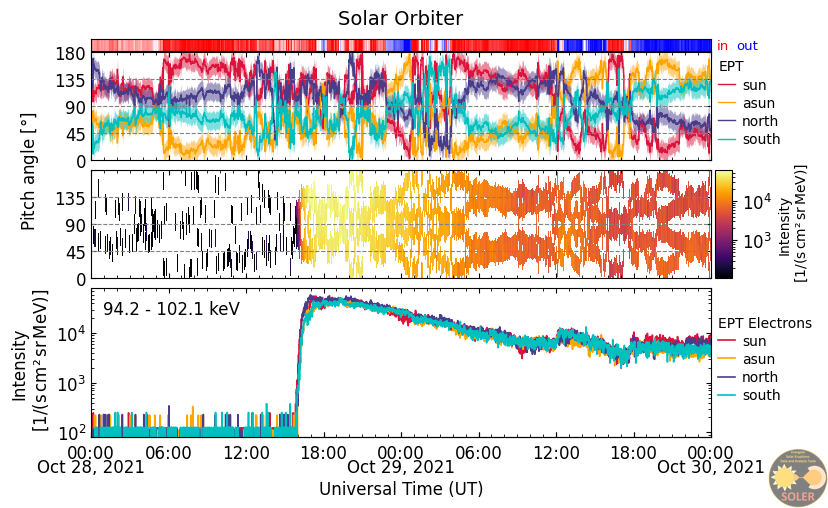

In [21]:
start_time = pd.to_datetime('2021-10-28 00:00:00')
end_time = pd.to_datetime('2021-10-30 00:00:00')

event = run_SEPevent(data_path, spacecraft_instrument.value, start_time, end_time, species, channels=channels, averaging=averaging)
fig, axes = event.overview_plot()

# Background analysis and subtraction
#### Choose a background window!
To determine the (potentially time-dependent) intensity background we fit both, a constant and an exponentially decaying model to the sector-averaged background intensity. The better fit is automatically chosen based on the reduded chi-squares. Then the model is extrapolated in time and subtracted from the measured intensities.

The parameter corr_window_end determines the end of the extrapolated background subtraction. The background-subtracted anisotropy is only determined until this time.

Background window start: 2021-10-28 08:00:00
Background window end: 2021-10-28 15:00:00
Background correction window end: 2021-10-28 21:00:00
Reduced chi-squared (constant model): 0.18
Reduced chi-squared (exponential model): 0.18


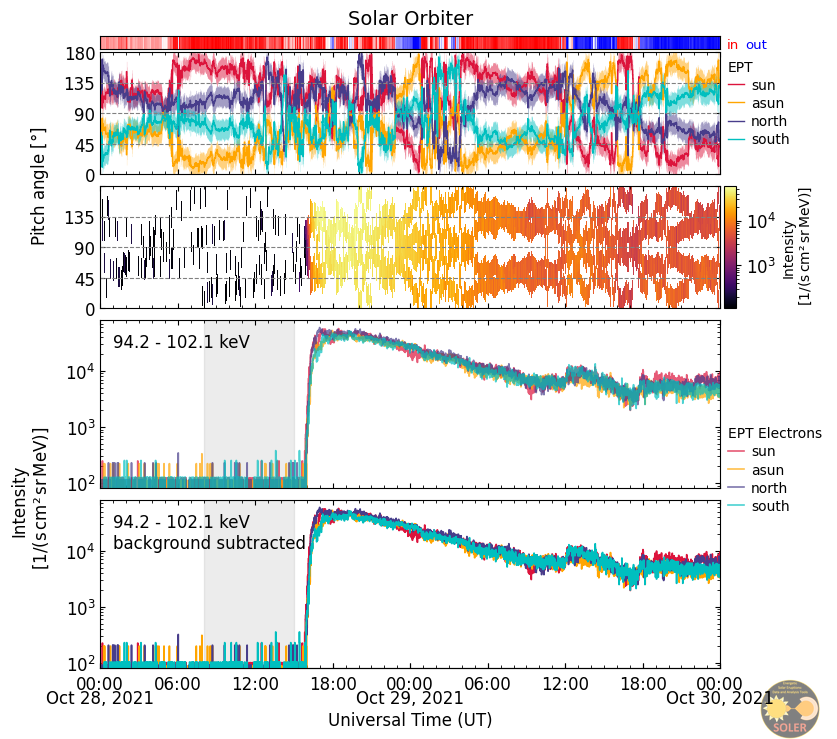

In [22]:
# chose a background window. Setting these to None will set default window [start_time, start_time + 5 hours] 
bg_start = pd.to_datetime('2021-10-28 08:00:00')  
bg_end =  pd.to_datetime('2021-10-28 15:00:00')  # None

# chose an end time for the background subtraction:
# if None then background subraction stops 3 hours after the end of the background window (bg_end)
corr_window_end = pd.to_datetime('2021-10-28 21:00:00') 

# resets background window and event.corr_window_end which is used to check that the background is not above the observations near the event start
event.set_background_window(bg_start, bg_end, corr_window_end)

# averaging (in minutes) used for the background analysis
bg_av_min = 10  

event.background_analysis_all(minutes=bg_av_min)
fig, axes = event.overview_plot_bgsub()

# Determine Anisotropies

Anisotropies are determined with and without background subtraction. Background-subtracted anisotropies are only calculated until 'corr_window_end' (see previous step).

### Choose the method for anisotropy calculation: 
- weighted-sum method (strongly suggested if only 4 viewing directions are available). The weighted-sum method is described in Brüdern et al. 2018, Central European Astrophysical Bulletin, 42, 2.

  
- weighted-sum method including bootstrapping: provides uncertainties for the anisotropy based on bootstrapping within intensity uncertainty ranges

- fit method: pitch-angle distributions are fitted with 2nd-order Legendre Polionomials to determine the anisotropy


Note that anisotropies during noisy low-intensity intervals (like right before the SEP event) cannot be trusted.

In [25]:
ani_method = 'fit'  # 'weighted_sum', 'weighted_sum_bootstrap', or 'fit'; 
                                       #'weighted_sum_bootstrap' should not be used for Wind (bootstrapping not implemented)!

event.calculate_anisotropy(ani_method=ani_method)
fig, axes = event.anisotropy_plot(ani_method=ani_method)

ZeroDivisionError: float division by zero

### Plot explanations: 

#### Anisotropy panel:

First order anisotropies without (black) and with (magenta) background subtraction. 
Gray and magenta shades around the anisotropy lines show the anisotropy uncertainty based 2.5 and 95 percentiles resulting from the bootstrapping analysis based on counting rate statistics (and the background subtraction - magenta trace) (only shown when `ani_method='weighted_sum_bootstrap'`).

Gray shades at the top and bottom of the panel show anisotropy values that cannot be determined with the instrument's pitch-angle coverage at that time.

----------------------
#### Plarity bar at the top of the plot marks the magnetic field polarity:

RED = INWARD, negative polarity, [90, 270] degrees

BLUE = OUTWARD, positive polarity, [270, 360] and [0, 90] degrees